# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Reading Data and Statistics 

In [2]:
df = pd.read_csv('2025_Yellow_Taxi_Trip_Data.csv')
df.head()

,Unnamed: 0,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
0,24870114,2,3/25/2025 8:55,3/25/2025 9:09,6,3.34,1,N,100,231,1,13.0,0.0,0.5,2.76,0.0,0.3,16.56
1,35634249,1,04-11-2025 14:53,04-11-2025 15:19,1,1.80,1,N,186,43,1,16.0,0.0,0.5,4.00,0.0,0.3,20.80
2,106203690,1,12/15/2025 7:26,12/15/2025 7:34,1,1.00,1,N,262,236,1,6.5,0.0,0.5,1.45,0.0,0.3,8.75
3,38942136,2,05-07-2025 13:17,05-07-2025 13:48,1,3.70,1,N,188,97,1,20.5,0.0,0.5,6.39,0.0,0.3,27.69
4,30841670,2,4/15/2025 23:32,4/15/2025 23:49,1,4.37,1,N,4,112,2,16.5,0.5,0.5,0.00,0.0,0.3,17.80


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22699 entries, 0 to 22698
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             22699 non-null  int64  
 1   VendorID               22699 non-null  int64  
 2   tpep_pickup_datetime   22699 non-null  object 
 3   tpep_dropoff_datetime  22699 non-null  object 
 4   passenger_count        22699 non-null  int64  
 5   trip_distance          22699 non-null  float64
 6   RatecodeID             22699 non-null  int64  
 7   store_and_fwd_flag     22699 non-null  object 
 8   PULocationID           22699 non-null  int64  
 9   DOLocationID           22699 non-null  int64  
 10  payment_type           22699 non-null  int64  
 11  fare_amount            22699 non-null  float64
 12  extra                  22699 non-null  float64
 13  mta_tax                22699 non-null  float64
 14  tip_amount             22699 non-null  float64
 15  to

,Unnamed: 0,VendorID,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
count,2.269900e+04,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000,22699.000000
mean,5.675849e+07,1.556236,1.642319,2.913313,1.043394,162.412353,161.527997,1.336887,13.026629,0.333275,0.497445,1.835781,0.312542,0.299551,16.310502
std,3.274493e+07,0.496838,1.285231,3.653171,0.708391,66.633373,70.139691,0.496211,13.243791,0.463097,0.039465,2.800626,1.399212,0.015673,16.097295
min,1.212700e+04,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,-120.000000,-1.000000,-0.500000,0.000000,0.000000,-0.300000,-120.300000
25%,2.852056e+07,1.000000,1.000000,0.990000,1.000000,114.000000,112.000000,1.000000,6.500000,0.000000,0.500000,0.000000,0.000000,0.300000,8.750000
50%,5.673150e+07,2.000000,1.000000,1.610000,1.000000,162.000000,162.000000,1.000000,9.500000,0.000000,0.500000,1.350000,0.000000,0.300000,11.800000
75%,8.537452e+07,2.000000,2.000000,3.060000,1.000000,233.000000,233.000000,2.000000,14.500000,0.500000,0.500000,2.450000,0.000000,0.300000,17.800000
max,1.134863e+08,2.000000,6.000000,33.960000,99.000000,265.000000,265.000000,4.000000,999.990000,4.500000,0.500000,200.000000,19.100000,0.300000,1200.290000


# Data Cleaning

### Removing null values from imp variables 

In [4]:
df = df[df['trip_distance'] > 0]
df = df[df['fare_amount'] > 0]
df = df[df['total_amount'] > 0]

### Removing extreme Outliers 

In [5]:
df = df[df['fare_amount'] < 200]   
df = df[df['trip_distance'] < 30]

### Converting to datetime  

Dataset contains mixed Date format 

In [6]:
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'], format='mixed', dayfirst=False)
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'], format='mixed', dayfirst=False)

### Feature Engineering

In [7]:
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
df['month'] = df['tpep_pickup_datetime'].dt.month
df['is_peak'] = df['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']

In [8]:
EMISSION_FACTOR = 404  # gCO2 per mile (EPA 2023)
df['CO2_g'] = df['trip_distance'] * EMISSION_FACTOR
df['CO2_tonnes'] = df['CO2_g'] / 1e6


Fare fraction basically tells us how much of total amount is actual fare \(used in revenue scaling \)

In [9]:
FARE_FRACTION = df['fare_amount'].sum() / df['total_amount'].sum()
 
print("Total trips:", len(df))
print("Total revenue: $", round(df['total_amount'].sum(), 2))
print("Total VMT:", round(df['trip_distance'].sum(), 2), "miles")
print("Total CO2:", round(df['CO2_tonnes'].sum(), 2), "tonnes")
 

Total trips: 22527
Total revenue: $ 364095.35
Total VMT: 65871.31 miles
Total CO2: 26.61 tonnes


# Exploratory Data Analysis 

### Demand by Hour 

/tmp/ipykernel_51/1734048022.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='hour', data=df, palette='Blues_d')


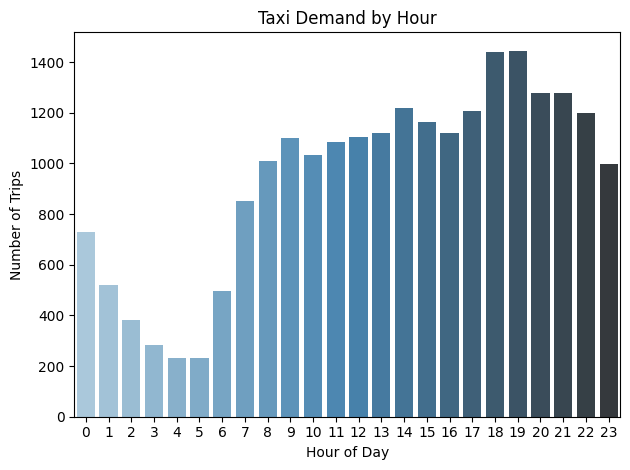

In [10]:
sns.countplot(x='hour', data=df, palette='Blues_d')
plt.title("Taxi Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.tight_layout()
plt.show()

### Fare Distribution

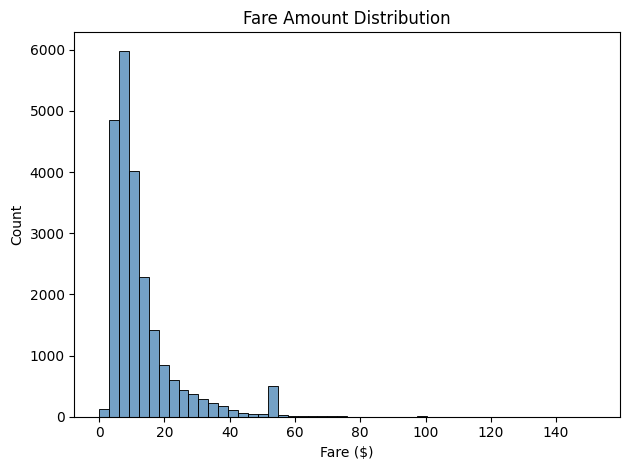

In [11]:
sns.histplot(df['fare_amount'], bins=50, color='steelblue')
plt.title("Fare Amount Distribution")
plt.xlabel("Fare ($)")
plt.tight_layout()
plt.show()

### Trip Distance Distribution

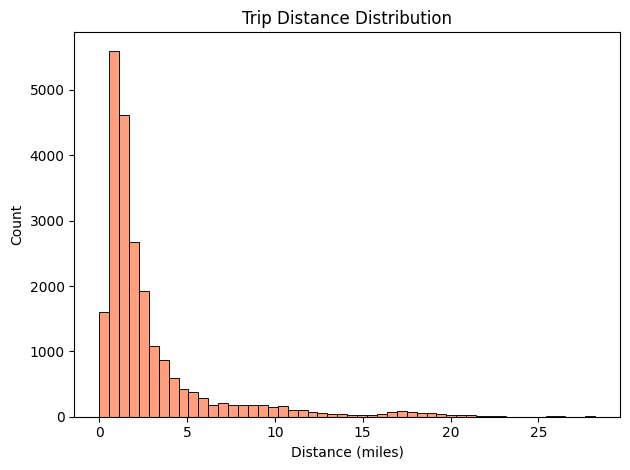

In [12]:
sns.histplot(df['trip_distance'], bins=50, color='coral')
plt.title("Trip Distance Distribution")
plt.xlabel("Distance (miles)")
plt.tight_layout()
plt.show()

### Fare vs Trip Distance 

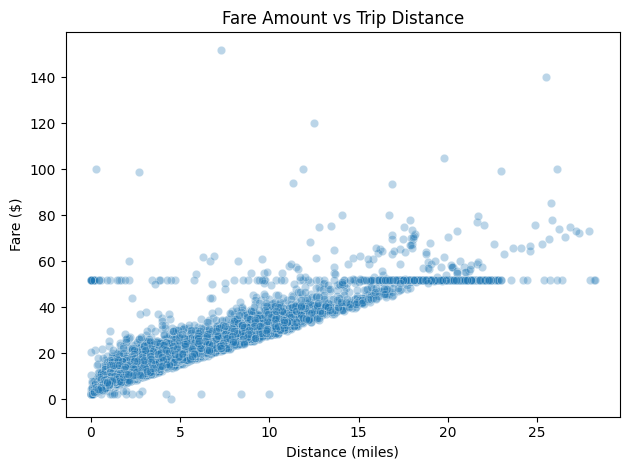

In [13]:
sns.scatterplot(x='trip_distance', y='fare_amount', data=df, alpha=0.3)
plt.title("Fare Amount vs Trip Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Fare ($)")
plt.tight_layout()
plt.show()

### Demand heatmap by hour and day 

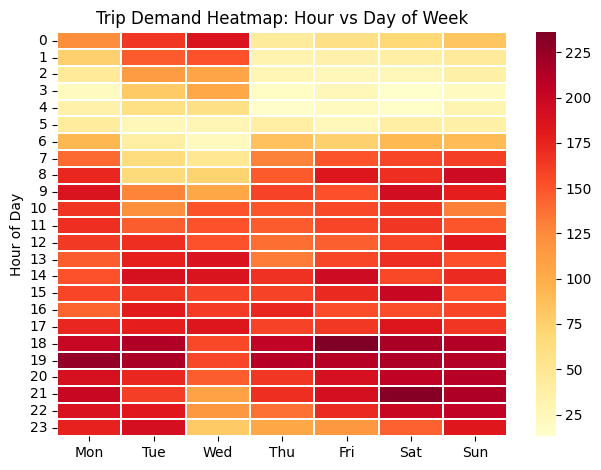

In [14]:
pivot = df.pivot_table(values='fare_amount', index='hour', columns='day_of_week', aggfunc='count')
pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title("Trip Demand Heatmap: Hour vs Day of Week")
plt.ylabel("Hour of Day")
plt.tight_layout()
plt.show()

### Fare per mile by top pickup zones 

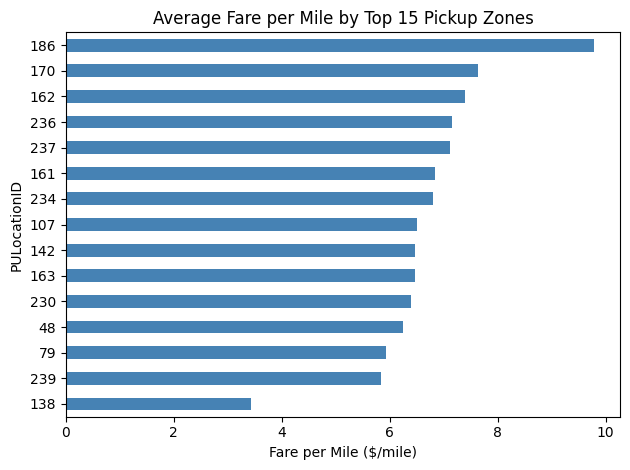

In [15]:
top_zones = df['PULocationID'].value_counts().head(15).index
zone_fare = df[df['PULocationID'].isin(top_zones)].groupby('PULocationID')['fare_per_mile'].mean().sort_values()
zone_fare.plot(kind='barh', color='steelblue')
plt.title("Average Fare per Mile by Top 15 Pickup Zones")
plt.xlabel("Fare per Mile ($/mile)")
plt.tight_layout()
plt.show()

# Demand Model 

Aggregate to zone\-hour level \(this is where we predict demand\)

In [16]:
demand_df = df.groupby(['PULocationID', 'hour', 'day_of_week', 'month']).agg(
    trip_count   = ('fare_amount', 'count'),
    avg_fare     = ('fare_amount', 'mean'),
    avg_distance = ('trip_distance', 'mean'),
    avg_duration = ('trip_duration', 'mean'),
    total_revenue= ('total_amount', 'sum'),
    total_vmt    = ('trip_distance', 'sum')
).reset_index()
 
demand_df['is_peak'] = demand_df['hour'].isin([7, 8, 9, 17, 18, 19, 20]).astype(int)
demand_df['is_weekend'] = (demand_df['day_of_week'] >= 5).astype(int)
 
X = demand_df[['avg_fare', 'avg_distance', 'hour', 'day_of_week', 'month', 'PULocationID', 'is_peak', 'is_weekend']]
y = demand_df['trip_count']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression 

In [17]:

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Linear Regression R2:", round(r2_score(y_test, pred_lr), 4))
print("Linear Regression RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_lr)), 4))

Linear Regression R2: 0.0052
Linear Regression RMSE: 0.4347


# Random Forest 

In [18]:

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Random Forest R2:", round(r2_score(y_test, pred_rf), 4))
print("Random Forest RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_rf)), 4))

Random Forest R2: 0.1426
Random Forest RMSE: 0.4035


# Gradient Boost 

In [19]:

gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
print("GBM R2:", round(r2_score(y_test, pred_gb), 4))
print("GBM RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_gb)), 4))

GBM R2: 0.3769
GBM RMSE: 0.344


### Feature Importance from Gradient Boost Model 

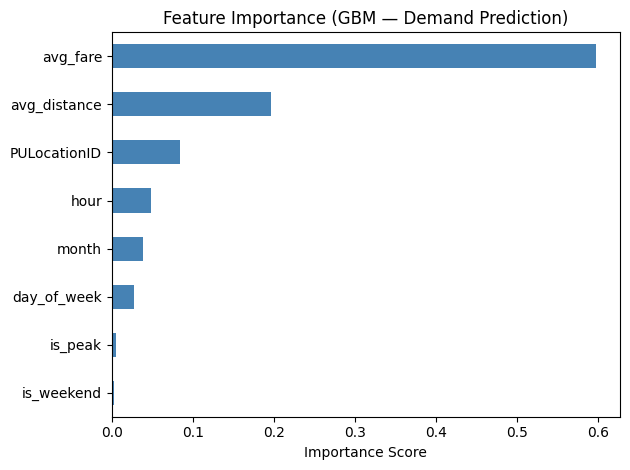

In [20]:
# feature importance from GBM
fi = pd.Series(gb.feature_importances_, index=X.columns).sort_values()
fi.plot(kind='barh', color='steelblue')
plt.title("Feature Importance (GBM — Demand Prediction)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

### Predicted vs Actual Demand 

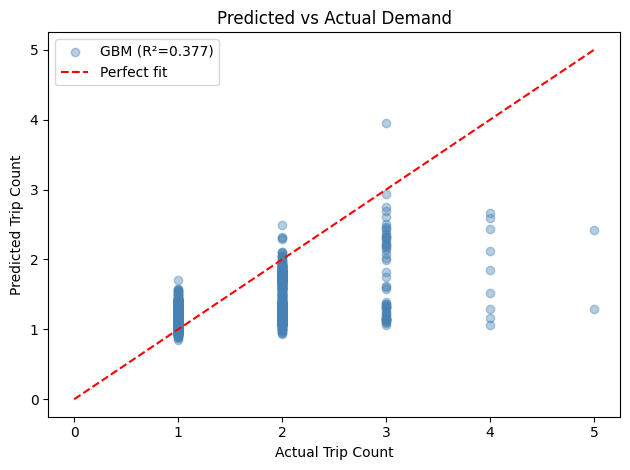

In [21]:
# predicted vs actual
plt.scatter(y_test, pred_gb, alpha=0.4, color='steelblue', label=f'GBM (R²={round(r2_score(y_test, pred_gb), 3)})')
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect fit')
plt.xlabel("Actual Trip Count")
plt.ylabel("Predicted Trip Count")
plt.title("Predicted vs Actual Demand")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
ELASTICITY = -0.4
CURRENT_REVENUE = df['total_amount'].sum()
CURRENT_VMT = df['trip_distance'].sum()
CURRENT_CO2 = CURRENT_VMT * EMISSION_FACTOR  # in grams

### Fare Scenario Simulation

Formulas: 

new\_demand = current\_demand \* \(1 \+ elasticity \* fare\_change\_pct\)
new\_revenue = current\_revenue \* \(1 \+ fare\_change \* fare\_fraction\) \* demand\_multiplier

In [23]:
results = []
for pct in [-0.20, -0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20]:
    dm = 1 + ELASTICITY * pct
    new_revenue = CURRENT_REVENUE * (1 + pct * FARE_FRACTION) * dm
    new_vmt = CURRENT_VMT * dm
    new_co2 = new_vmt * EMISSION_FACTOR
 
    results.append({
        'fare_change': f'{pct*100:+.0f}%',
        'demand_multiplier': round(dm, 3),
        'revenue': round(new_revenue, 2),
        'revenue_change_pct': round((new_revenue - CURRENT_REVENUE) / CURRENT_REVENUE * 100, 2),
        'vmt': round(new_vmt, 2),
        'co2_tonnes': round(new_co2 / 1e6, 3),
        'co2_change_pct': round((new_co2 - CURRENT_CO2) / CURRENT_CO2 * 100, 2)
    })
 
scenarios = pd.DataFrame(results)
print(scenarios)

  fare_change  demand_multiplier    revenue  revenue_change_pct       vmt  \
0        -20%               1.08  330449.36               -9.24  71141.01   
1        -15%               1.06  339732.71               -6.69  69823.59   
2        -10%               1.04  348434.83               -4.30  68506.16   
3         -5%               1.02  356555.71               -2.07  67188.74   
4         +0%               1.00  364095.35                0.00  65871.31   
5         +5%               0.98  371053.75                1.91  64553.88   
6        +10%               0.96  377430.92                3.66  63236.46   
7        +15%               0.94  383226.85                5.25  61919.03   
8        +20%               0.92  388441.55                6.69  60601.61   

   co2_tonnes  co2_change_pct  
0      28.741             8.0  
1      28.209             6.0  
2      27.676             4.0  
3      27.144             2.0  
4      26.612             0.0  
5      26.080            -2.0  
6    

### Revenue across the scenarios

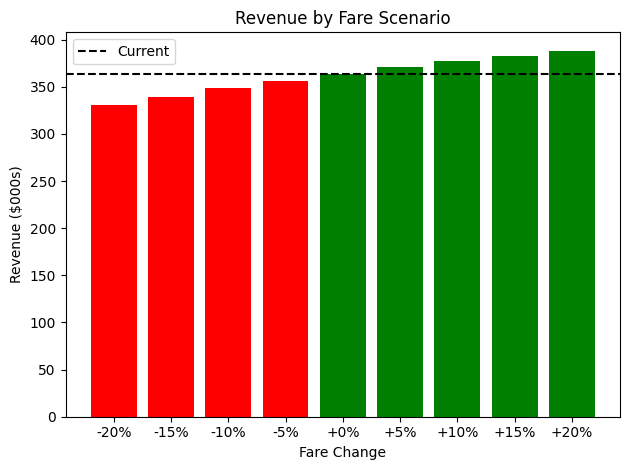

In [24]:
# Plotting revenue across scenarios
plt.bar(scenarios['fare_change'], scenarios['revenue'] / 1000,
        color=['red' if x < 0 else 'green' for x in scenarios['revenue_change_pct']])
plt.axhline(CURRENT_REVENUE / 1000, color='black', linestyle='--', label='Current')
plt.title("Revenue by Fare Scenario")
plt.xlabel("Fare Change")
plt.ylabel("Revenue ($000s)")
plt.legend()
plt.tight_layout()
plt.show()

### CO2 across Scenarios \(Revenue vs Emissions\)

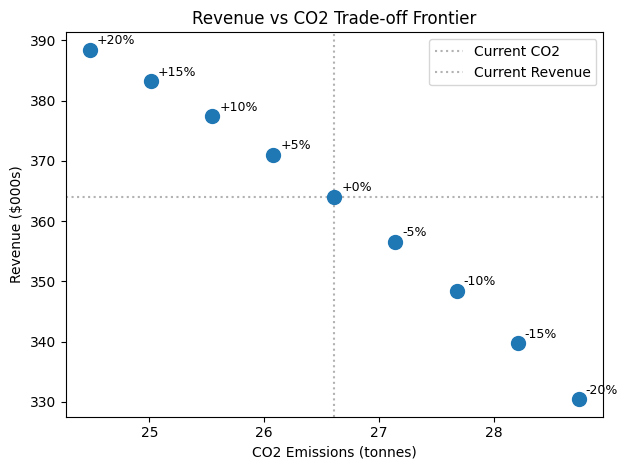

In [25]:
# revenue vs emissions frontier
plt.scatter(scenarios['co2_tonnes'], scenarios['revenue'] / 1000, s=100, zorder=5)
for _, row in scenarios.iterrows():
    plt.annotate(row['fare_change'], (row['co2_tonnes'], row['revenue'] / 1000),
                 textcoords='offset points', xytext=(5, 4), fontsize=9)
plt.axvline(CURRENT_CO2 / 1e6, color='gray', linestyle=':', alpha=0.6, label='Current CO2')
plt.axhline(CURRENT_REVENUE / 1000, color='gray', linestyle=':', alpha=0.6, label='Current Revenue')
plt.xlabel("CO2 Emissions (tonnes)")
plt.ylabel("Revenue ($000s)")
plt.title("Revenue vs CO2 Trade-off Frontier")
plt.legend()
plt.tight_layout()
plt.show()

### Regional Optimisation 

Instead of a blanket fare change in common , raising fares only in high VMT zones, this reduces emissions where it matters most without hurting demand in efficient short\-trip zones 

In [26]:
regional = df.groupby('PULocationID').agg(
    trips        = ('fare_amount', 'count'),
    avg_fare     = ('fare_amount', 'mean'),
    avg_distance = ('trip_distance', 'mean'),
    total_revenue= ('total_amount', 'sum'),
    total_vmt    = ('trip_distance', 'sum')
).reset_index()
 
regional['fare_per_mile'] = regional['avg_fare'] / regional['avg_distance']
regional['emission_tonnes'] = regional['total_vmt'] * EMISSION_FACTOR / 1e6

### Classifying zones by VMT quartile

In [27]:
regional['vmt_quartile'] = pd.qcut(regional['total_vmt'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4_HighVMT'])
high_vmt_zones = regional[regional['vmt_quartile'] == 'Q4_HighVMT']['PULocationID'].tolist()
 
print(f"Number of high-VMT zones: {len(high_vmt_zones)}")
print(f"These zones cover {regional[regional['vmt_quartile']=='Q4_HighVMT']['total_vmt'].sum():,.0f} miles")

Number of high-VMT zones: 37
These zones cover 56,443 miles


### Applying \+10% fare only in High\-VMT zones 

In [28]:
FARE_INCREASE = 0.10
dm_high = 1 + ELASTICITY * FARE_INCREASE
mask_high = df['PULocationID'].isin(high_vmt_zones)
 
opt_revenue = (
    (df.loc[mask_high, 'total_amount'] * (1 + FARE_INCREASE * FARE_FRACTION) * dm_high).sum() +
    df.loc[~mask_high, 'total_amount'].sum()
)
opt_vmt = (
    (df.loc[mask_high, 'trip_distance'] * dm_high).sum() +
    df.loc[~mask_high, 'trip_distance'].sum()
)
opt_co2 = opt_vmt * EMISSION_FACTOR
 
print("\n--- Targeted strategy results ---")
print(f"Revenue:  ${opt_revenue:,.0f}  ({(opt_revenue-CURRENT_REVENUE)/CURRENT_REVENUE*100:+.1f}% vs current)")
print(f"VMT:      {opt_vmt:,.0f} miles  ({(opt_vmt-CURRENT_VMT)/CURRENT_VMT*100:+.1f}% vs current)")
print(f"CO2:      {opt_co2/1e6:.2f} tonnes  ({(opt_co2-CURRENT_CO2)/CURRENT_CO2*100:+.1f}% vs current)")


--- Targeted strategy results ---
Revenue:  $375,522  (+3.1% vs current)
VMT:      63,614 miles  (-3.4% vs current)
CO2:      25.70 tonnes  (-3.4% vs current)


### VMT vs fare per mile 

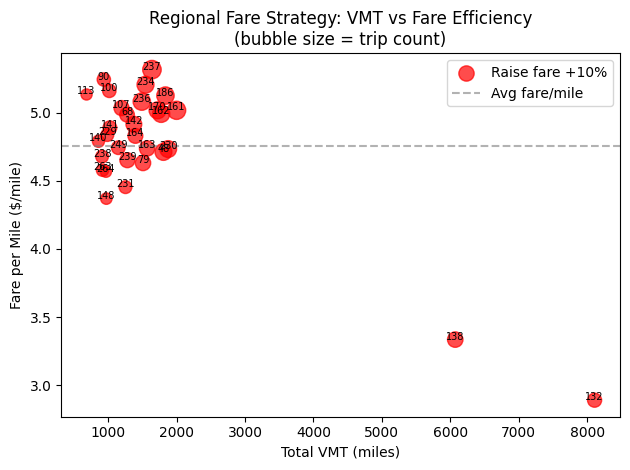

In [29]:
top30 = regional.sort_values('trips', ascending=False).head(30).copy()
top30['strategy'] = top30['PULocationID'].isin(high_vmt_zones).map({True: 'Raise fare +10%', False: 'Keep current'})
 
colors = {'Raise fare +10%': 'red', 'Keep current': 'steelblue'}
for strategy, grp in top30.groupby('strategy'):
    plt.scatter(grp['total_vmt'], grp['fare_per_mile'],
                s=grp['trips'] / 5, color=colors[strategy], label=strategy, alpha=0.7)
    for _, row in grp.iterrows():
        plt.annotate(str(int(row['PULocationID'])), (row['total_vmt'], row['fare_per_mile']),
                     fontsize=7, ha='center')
plt.axhline(top30['fare_per_mile'].mean(), color='gray', linestyle='--', alpha=0.6, label='Avg fare/mile')
plt.xlabel("Total VMT (miles)")
plt.ylabel("Fare per Mile ($/mile)")
plt.title("Regional Fare Strategy: VMT vs Fare Efficiency\n(bubble size = trip count)")
plt.legend()
plt.tight_layout()
plt.show()

### Final comparision Bar Chart 

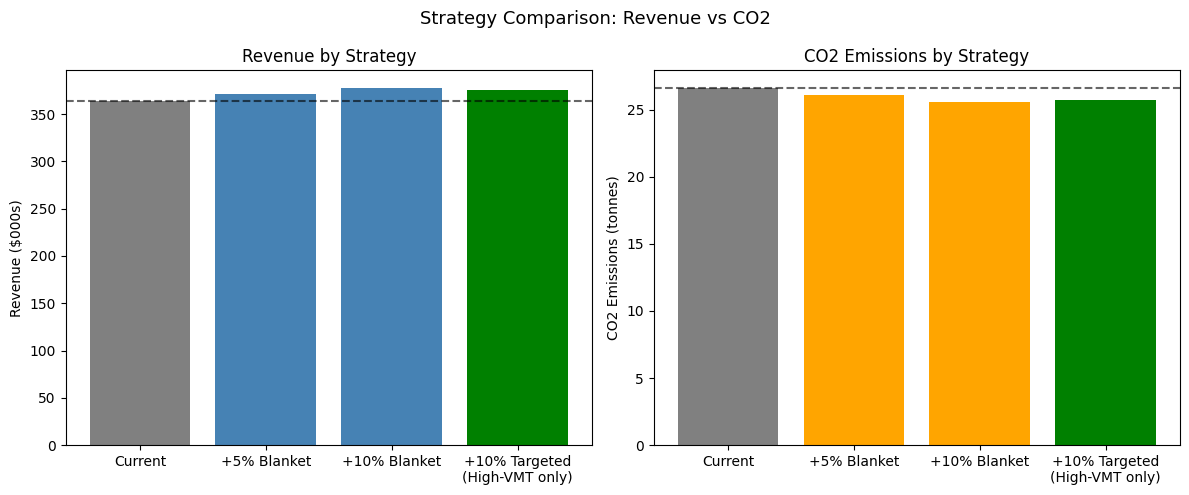

In [30]:
strategies = ['Current', '+5% Blanket', '+10% Blanket', '+10% Targeted\n(High-VMT only)']
revenues = [
    CURRENT_REVENUE,
    CURRENT_REVENUE * (1 + 0.05 * FARE_FRACTION) * (1 + ELASTICITY * 0.05),
    CURRENT_REVENUE * (1 + 0.10 * FARE_FRACTION) * (1 + ELASTICITY * 0.10),
    opt_revenue
]
co2s = [
    CURRENT_CO2 / 1e6,
    CURRENT_VMT * (1 + ELASTICITY * 0.05) * EMISSION_FACTOR / 1e6,
    CURRENT_VMT * (1 + ELASTICITY * 0.10) * EMISSION_FACTOR / 1e6,
    opt_co2 / 1e6
]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(strategies, [r / 1000 for r in revenues], color=['gray', 'steelblue', 'steelblue', 'green'])
axes[0].axhline(CURRENT_REVENUE / 1000, color='black', linestyle='--', alpha=0.6)
axes[0].set_title("Revenue by Strategy")
axes[0].set_ylabel("Revenue ($000s)")
 
axes[1].bar(strategies, co2s, color=['gray', 'orange', 'orange', 'green'])
axes[1].axhline(CURRENT_CO2 / 1e6, color='black', linestyle='--', alpha=0.6)
axes[1].set_title("CO2 Emissions by Strategy")
axes[1].set_ylabel("CO2 Emissions (tonnes)")
 
plt.suptitle("Strategy Comparison: Revenue vs CO2", fontsize=13)
plt.tight_layout()
plt.show()